In [33]:

import numpy as np
import pandas as pd

In [34]:
centroids = np.load('/home/alexmatthews/Documents/Honors/Centroid_analysis/sep18_davies_bouldin_cleaned_tail_base_x_centroids_k36_delSize0_delPosP66.npy')

array([[-9.27896615e-02,  5.00773062e-01, -8.88737045e-02,
        -3.77625193e-01,  1.20922124e-01,  3.77625191e-01,
        -1.20922127e-01, -4.18153878e-02, -5.29313797e-02,
         1.41600507e+00, -2.96266638e-02,  1.27004188e+00,
        -2.36130835e-01,  5.22370958e-01, -3.99575712e-01,
        -5.15049454e-01],
       [ 1.34217135e+00,  9.78852880e-01,  2.71222817e-01,
         1.38676252e+00,  4.92810662e+00, -1.38676250e+00,
        -4.92810662e+00,  7.00640993e-01,  5.33025099e-01,
        -1.31995708e+00,  2.85051004e-01, -1.29359183e+00,
         7.26481906e-02, -1.19115979e+00, -2.96095765e-02,
        -1.03784989e+00],
       [-3.71164066e-01, -1.33589810e-02,  1.28673555e-04,
         4.69581246e-03,  1.62803905e-02, -4.69581248e-03,
        -1.62803906e-02, -2.21373504e-02, -1.99839964e-02,
        -3.74618755e-03, -1.50499707e-02, -2.61559990e-03,
        -1.08858336e-02, -9.10227179e-04, -1.31084894e-02,
         2.69005815e-04],
       [-5.89632988e-01,  1.42602943e

In [7]:
feature_str_overall = [
"thrust_mm_s", "slip_mm_s", "yaw_rad_s", 
"left_eye_x_diff", "left_eye_y_diff", "right_eye_x_diff", "right_eye_y_diff", 
"tail_base_x_diff", "tail_1_x_diff", "tail_1_y_diff", "tail_2_x_diff", 
"tail_2_y_diff", "tail_3_x_diff", "tail_3_y_diff", "tail_end_x_diff", 
"tail_end_y_diff"
]   
len(feature_str_overall)

16

In [6]:
len(centroids[0])

16

# de z scoring

In [42]:
def de_zscore_centroids(centroids, mu, sigma):
    """
    Reverses the z-scoring process for centroids using the original mean (mu) and standard deviation (sigma).
    """
    centroids_de_zscored = np.zeros(shape=centroids.shape)
    for i in range(centroids.shape[1]):
        centroids_de_zscored[:, i] = centroids[:, i] * sigma[i] + mu[i]
    return centroids_de_zscored
    

In [31]:
mu_sigma_df_path = '/home/alexmatthews/Documents/Honors/Centroid_analysis/4AP_ND2_PTZ_with_bp_diff_FAST_without_empty_wells_cleaned_more_rigorous_muSigma.csv'
features_clustered = [0,1,2,16, 17,18,19,20,21,22,23,24,25,26,27,28]
mu_sigma_df_full = pd.read_csv(mu_sigma_df_path)
print("mu_sigma_df_full ", mu_sigma_df_full)
mu_sigma_df=  mu_sigma_df_full.iloc[features_clustered] 

mu_sigma_df_for_unfolding_positional_means=mu_sigma_df_full.iloc[3:16]

centroids_uf = de_zscore_centroids(centroids, mu_sigma_df['mu'].to_numpy(), mu_sigma_df['sigma'].to_numpy())

# plotting functions

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized

def plot_clusters(horizontal_movement, vertical_movement):
    plt.figure(figsize=(8, 6))
    plt.scatter(horizontal_movement, vertical_movement, c='blue', alpha=0.7, edgecolors='w', s=100)
    
    for i, (x, y) in enumerate(zip(horizontal_movement, vertical_movement)):
        plt.text(x, y, str(i), fontsize=9, ha='right', va='bottom')
    
    plt.xlabel('Normalized Horizontal Movement (Left/Right)')
    plt.ylabel('Normalized Vertical Movement (Up/Down)')
    plt.title('Cluster Movements')
    
    # Apply symmetrical logarithmic scale
    plt.yscale('symlog', linthresh=0.01, linscale=1)
    plt.xscale('symlog', linthresh=0.01, linscale=1)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.axhline(0, color='grey', linewidth=0.5)
    plt.axvline(0, color='grey', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()


In [40]:
mu_sigma_df_path = '/home/alexmatthews/Documents/Honors/Centroid_analysis/4AP_ND2_PTZ_with_bp_diff_FAST_without_empty_wells_cleaned_more_rigorous_muSigma.csv'
features_clustered = [0,1,2,16, 17,18,19,20,21,22,23,24,25,26,27,28]
mu_sigma_df_full = pd.read_csv(mu_sigma_df_path)
mu_sigma_df_full['mu'].to_numpy()

array([ 2.76652452e+00,  4.71151348e-02,  2.00427054e-04, -2.08883285e-01,
        4.68261887e+00,  2.08883285e-01, -4.68261887e+00,  1.36337042e+01,
        2.37199520e+01,  4.02895583e-01,  3.34699298e+01,  7.78627782e-01,
        4.26700656e+01,  1.11552123e+00,  5.15406451e+01,  1.52174106e+00,
       -4.48112393e-05, -4.46477240e-06,  4.48112384e-05,  4.46477068e-06,
        2.75885555e-05,  2.02304956e-05,  8.32105754e-05,  3.60492093e-05,
        1.03402089e-04,  5.19304378e-05,  1.40130065e-04,  1.15779838e-04,
        1.73466512e-04])

mu_sigma_df_full            mu      sigma
0   2.766525   6.701403
1   0.047115   4.289238
2   0.000200  31.672854
16 -0.000045   0.515662
17 -0.000004   0.555696
18  0.000045   0.515662
19  0.000004   0.555696
20  0.000028   0.913202
21  0.000020   1.506109
22  0.000083   1.882984
23  0.000036   2.561193
24  0.000103   4.139024
25  0.000052   3.810152
26  0.000140   6.041641
27  0.000116   5.188892
28  0.000173   7.529578


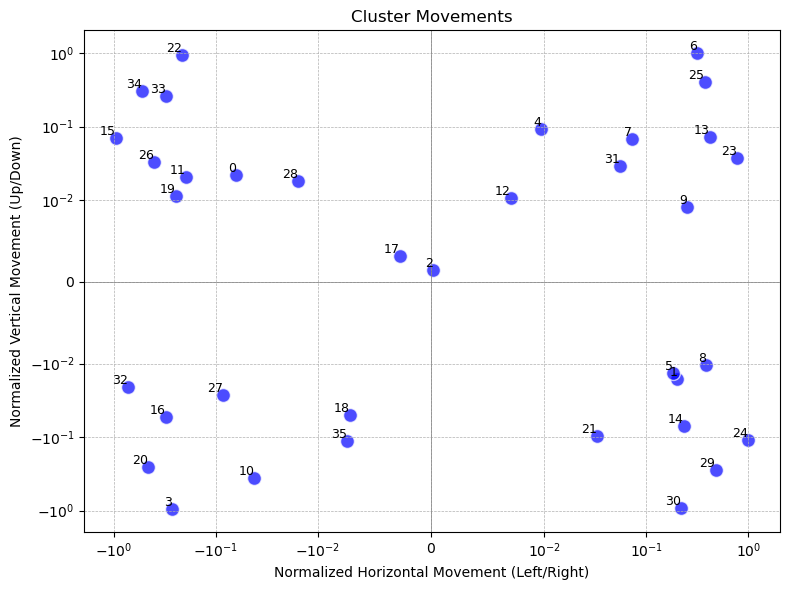

In [46]:
centroids = np.load('/home/alexmatthews/Documents/Honors/Centroid_analysis/sep18_davies_bouldin_cleaned_tail_base_x_centroids_k36_delSize0_delPosP66.npy')
# Define the feature names

mu_sigma_df_path = '/home/alexmatthews/Documents/Honors/Centroid_analysis/4AP_ND2_PTZ_with_bp_diff_FAST_without_empty_wells_cleaned_more_rigorous_muSigma.csv'
features_clustered = [0,1,2,16, 17,18,19,20,21,22,23,24,25,26,27,28]
mu_sigma_df_full = pd.read_csv(mu_sigma_df_path)

mu_sigma_df=  mu_sigma_df_full.iloc[features_clustered] 
print("mu_sigma_df_full ", mu_sigma_df)



centroids_uf = de_zscore_centroids(centroids, mu_sigma_df['mu'].to_numpy(), mu_sigma_df['sigma'].to_numpy())



feature_str_overall = [
    "thrust_mm_s", "slip_mm_s", "yaw_rad_s",
    "left_eye_x_diff", "left_eye_y_diff", "right_eye_x_diff", "right_eye_y_diff",
    "tail_base_x_diff", "tail_1_x_diff", "tail_1_y_diff", "tail_2_x_diff",
    "tail_2_y_diff", "tail_3_x_diff", "tail_3_y_diff", "tail_end_x_diff",
    "tail_end_y_diff"
]

# Get indices of x_diff and y_diff components
x_diff_indices, y_diff_indices = get_diff_indices(feature_str_overall)

# Compute movement sums
vertical_movement, horizontal_movement = compute_movement_sums(centroids_uf, x_diff_indices, y_diff_indices)

# Normalize movement sums
vertical_movement_norm, horizontal_movement_norm = normalize_movement_sums(vertical_movement, horizontal_movement)

# Plot the clusters
plot_clusters(horizontal_movement_norm, vertical_movement_norm)


# Plotting colors


In [459]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized



def get_label_position(i, x, y, default_offset=(0, 0)):
    """
    Determine label position offsets and alignment based on cluster index.

    Parameters:
        i (int): Cluster index.
        x (float): Original x-coordinate.
        y (float): Original y-coordinate.
        default_offset (tuple): Default offset for labels.

    Returns:
        tuple: (x_offset, y_offset, ha, va)
    """
    if i == 17:
        return (x -0.002 , y , 'right', 'top')    # Left and Down
    elif i == 2:
        return (x, y - 0.008, 'center', 'top')          # Directly Below
    elif i == 12:
        return (x + 0.005, y - 0.005, 'left', 'bottom')  # Top Right
    else:
        return (x, y, 'right', 'bottom')               # Default Position


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def plot_clusters(horizontal_movement, vertical_movement, cluster_sets, group_colors, rest_label="Other Swimming Behaviours",legend_ncols =3):
    """
    Plot clusters with specified highlight groups and colors, keeping the axes square and legend on the right.

    Parameters:
        horizontal_movement (list or np.array): Array-like list of horizontal movements for each cluster.
        vertical_movement (list or np.array): Array-like list of vertical movements for each cluster.
        cluster_sets (dict): Dictionary defining groups of cluster indices to highlight.
        group_colors (dict): Dictionary defining colors for each group in `cluster_sets`.
    """
    # Convert to NumPy arrays for consistency
    horizontal_movement = np.array(horizontal_movement)
    vertical_movement = np.array(vertical_movement)
    
    # Create figure and axes, ensuring the plot is square
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Total number of clusters
    num_clusters = len(horizontal_movement)
    indices = np.arange(num_clusters)

    # Identify which clusters are in the predefined sets
    clusters_in_sets = set()
    for cluster_indices in cluster_sets.values():
        clusters_in_sets.update(cluster_indices)

    # Plot clusters that are *not* in any specified set (Other Clusters)
    other_indices = [i for i in indices if i not in clusters_in_sets]
    if other_indices:
        ax.scatter(horizontal_movement[other_indices], vertical_movement[other_indices],
                   c='grey', alpha=0.3, edgecolors='w', s=100)
        for i in other_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = get_label_position(i, x, y)
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)

    # Plot clusters that are in each specified group set
    legend_elements = []
    for group_name, cluster_indices in cluster_sets.items():
        color = group_colors.get(group_name, 'blue')  # Default to 'blue' if color is not specified
        cluster_indices = np.array(cluster_indices)

        # Plot clusters in this group with specified color and higher alpha
        ax.scatter(horizontal_movement[cluster_indices], vertical_movement[cluster_indices],
                   c=color, alpha=1.0, edgecolors='w', s=100, label=group_name)

        # Annotate clusters in the current group
        for i in cluster_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = get_label_position(i, x, y)
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)
        # Add the group to the custom legend elements
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=group_name,
                                      markerfacecolor=color, markersize=10))

    # Add 'Other Clusters' to the legend if applicable
    if other_indices:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=rest_label,
                                      markerfacecolor='grey', markersize=10, alpha=0.3))

    # Configure plot appearance
    ax.set_xlabel(' Sum of Vertical Component (max normalised)')
    ax.set_ylabel(' Sum of Horizontal Component (max normalised)')
    # ax.set_title('Cluster Movements')
    ax.set_aspect('equal', 'box')  # Keep the plot axes square

    # # Apply symmetrical logarithmic scale for better visualization


    # Add grid and reference lines at zero
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)

    # Place the legend on the right side of the plot without affecting the axes size
    # plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.8, -0.05), loc='upper center', ncol=2)
    plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=legend_ncols)


    
    # Adjust layout to keep axes square while leaving space for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Adjust the right boundary to make space for the legend

    # Show the final plot
    plt.show()


def plot_clusters_log_scale(horizontal_movement, vertical_movement, cluster_sets, group_colors, rest_label="Other Swimming Behaviours",legend_ncols =3):
    """
    Plot clusters with specified highlight groups and colors, keeping the axes square and legend on the right.

    Parameters:
        horizontal_movement (list or np.array): Array-like list of horizontal movements for each cluster.
        vertical_movement (list or np.array): Array-like list of vertical movements for each cluster.
        cluster_sets (dict): Dictionary defining groups of cluster indices to highlight.
        group_colors (dict): Dictionary defining colors for each group in `cluster_sets`.
    """
    # Convert to NumPy arrays for consistency
    horizontal_movement = np.array(horizontal_movement)
    vertical_movement = np.array(vertical_movement)
    
    # Create figure and axes, ensuring the plot is square
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Total number of clusters
    num_clusters = len(horizontal_movement)
    indices = np.arange(num_clusters)

    # Identify which clusters are in the predefined sets
    clusters_in_sets = set()
    for cluster_indices in cluster_sets.values():
        clusters_in_sets.update(cluster_indices)

    # Plot clusters that are *not* in any specified set (Other Clusters)
    other_indices = [i for i in indices if i not in clusters_in_sets]
    if other_indices:
        ax.scatter(horizontal_movement[other_indices], vertical_movement[other_indices],
                   c='grey', alpha=0.3, edgecolors='w', s=100)
        for i in other_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = x, y, 'right', 'bottom'
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)

    # Plot clusters that are in each specified group set
    legend_elements = []
    for group_name, cluster_indices in cluster_sets.items():
        color = group_colors.get(group_name, 'blue')  # Default to 'blue' if color is not specified
        cluster_indices = np.array(cluster_indices)

        # Plot clusters in this group with specified color and higher alpha
        ax.scatter(horizontal_movement[cluster_indices], vertical_movement[cluster_indices],
                   c=color, alpha=1.0, edgecolors='w', s=100, label=group_name)

        # Annotate clusters in the current group
        for i in cluster_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = x, y, 'right', 'bottom'
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)
        # Add the group to the custom legend elements
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=group_name,
                                      markerfacecolor=color, markersize=10))

    # Add 'Other Clusters' to the legend if applicable
    if other_indices:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=rest_label,
                                      markerfacecolor='grey', markersize=10, alpha=0.3))

    # Configure plot appearance
    ax.set_xlabel(' Sum of Vertical Component (max normalised)')
    ax.set_ylabel(' Sum of Horizontal Component (max normalised)')
    # ax.set_title('Cluster Movements')
    ax.set_aspect('equal', 'box')  # Keep the plot axes square

    # # Apply symmetrical logarithmic scale for better visualization
    ax.set_yscale('symlog', linthresh=0.01, linscale=1)
    ax.set_xscale('symlog', linthresh=0.01, linscale=1)

    # Add grid and reference lines at zero
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_yscale('symlog', linthresh=0.01, linscale=1)
    ax.set_xscale('symlog', linthresh=0.01, linscale=1)

    # Place the legend on the right side of the plot without affecting the axes size
    # plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.8, -0.05), loc='upper center', ncol=2)
    plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=legend_ncols)


    
    # Adjust layout to keep axes square while leaving space for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Adjust the right boundary to make space for the legend

    # Show the final plot
    plt.show()


mu_sigma_df_full            mu      sigma
0   2.766525   6.701403
1   0.047115   4.289238
2   0.000200  31.672854
16 -0.000045   0.515662
17 -0.000004   0.555696
18  0.000045   0.515662
19  0.000004   0.555696
20  0.000028   0.913202
21  0.000020   1.506109
22  0.000083   1.882984
23  0.000036   2.561193
24  0.000103   4.139024
25  0.000052   3.810152
26  0.000140   6.041641
27  0.000116   5.188892
28  0.000173   7.529578


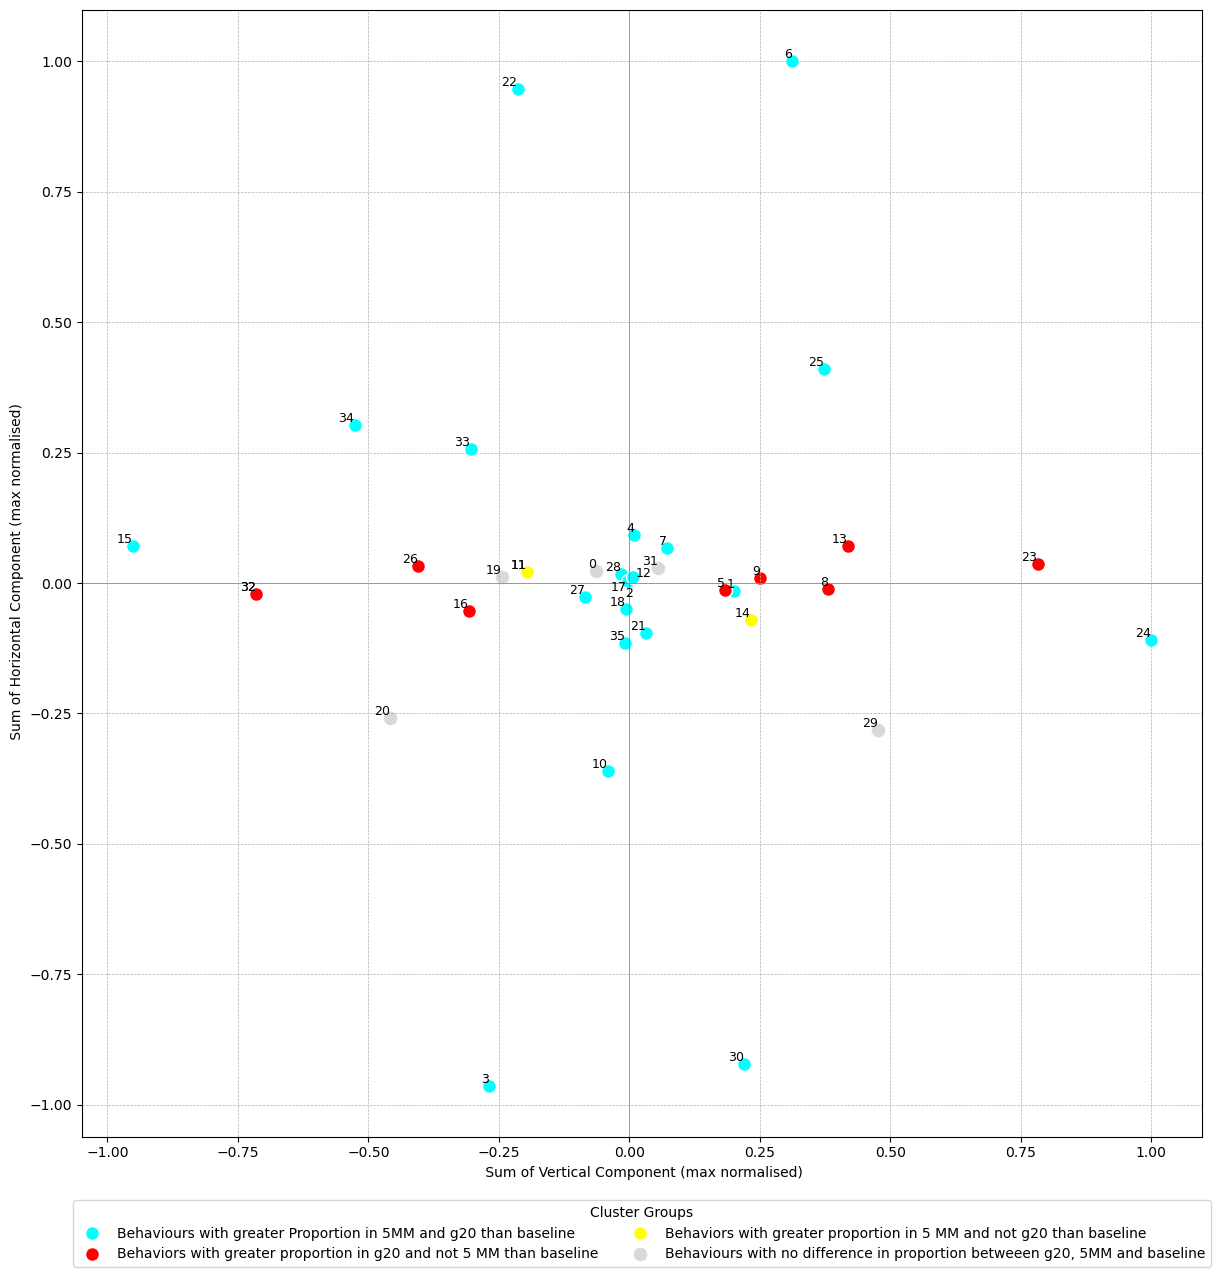

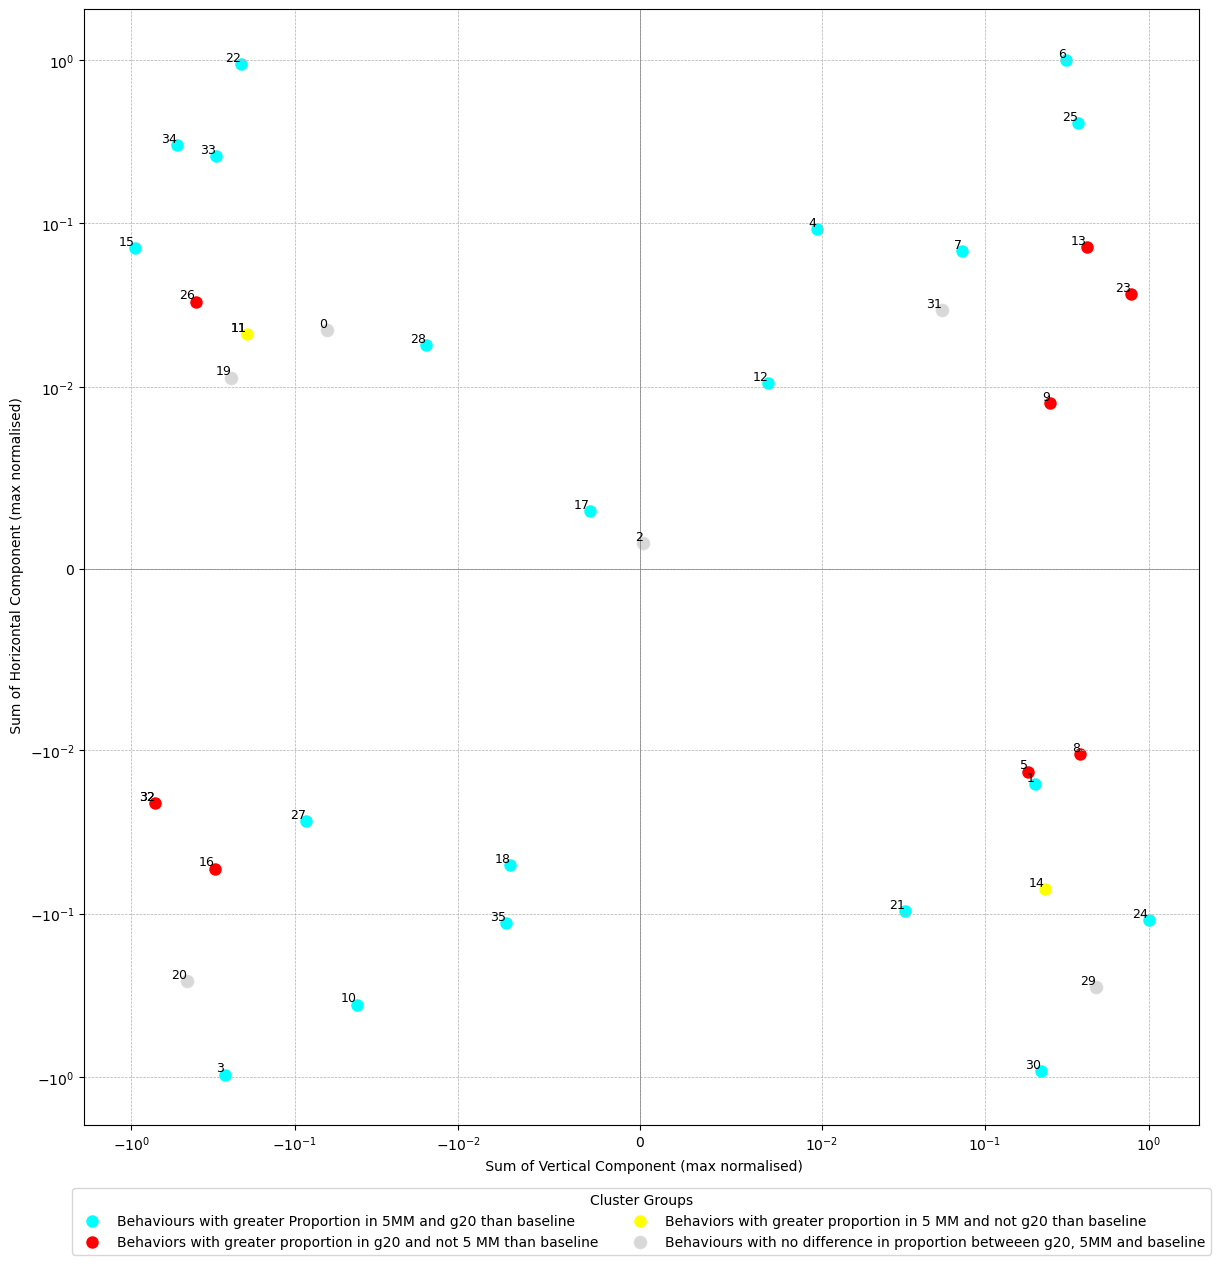

In [462]:
centroids = np.load('/home/alexmatthews/Documents/Honors/Centroid_analysis/sep18_davies_bouldin_cleaned_tail_base_x_centroids_k36_delSize0_delPosP66.npy')
# Define the feature names

mu_sigma_df_path = '/home/alexmatthews/Documents/Honors/Centroid_analysis/4AP_ND2_PTZ_with_bp_diff_FAST_without_empty_wells_cleaned_more_rigorous_muSigma.csv'
features_clustered = [0,1,2,16, 17,18,19,20,21,22,23,24,25,26,27,28]
mu_sigma_df_full = pd.read_csv(mu_sigma_df_path)

mu_sigma_df=  mu_sigma_df_full.iloc[features_clustered] 
print("mu_sigma_df_full ", mu_sigma_df)



centroids_uf = de_zscore_centroids(centroids, mu_sigma_df['mu'].to_numpy(), mu_sigma_df['sigma'].to_numpy())



feature_str_overall = [
    "thrust_mm_s", "slip_mm_s", "yaw_rad_s",
    "left_eye_x_diff", "left_eye_y_diff", "right_eye_x_diff", "right_eye_y_diff",
    "tail_base_x_diff", "tail_1_x_diff", "tail_1_y_diff", "tail_2_x_diff",
    "tail_2_y_diff", "tail_3_x_diff", "tail_3_y_diff", "tail_end_x_diff",
    "tail_end_y_diff"
]

# Get indices of x_diff and y_diff components
x_diff_indices, y_diff_indices = get_diff_indices(feature_str_overall)

# Compute movement sums
vertical_movement, horizontal_movement = compute_movement_sums(centroids_uf, x_diff_indices, y_diff_indices)

# Normalize movement sums
vertical_movement_norm, horizontal_movement_norm = normalize_movement_sums(vertical_movement, horizontal_movement)


# Define your cluster sets and group colors
# cluster_sets = {
#     '4-AP greater than PTZ': [4, 12, 28, 18],
#     '4-AP Rescued by VPA': [13, 20, 29],
# }

# group_colors = {
#     '4-AP greater than PTZ': 'red',
#     '4-AP Rescued by VPA': 'green',
# }



# cluster_sets = {
#     'CSC': [22, 3, 6, 30],
#     'UTB': [34, 32,25,23],
#     'UTB Early': [27,7],
#     'Shrug':[4,12,18,21,35]
# }

# group_colors = {
#     'CSC': 'red',
#     'UTB': 'green',
#     'UTB Early': 'yellow',
#     'Shrug':'blue'
# }



# cluster_sets = {
#     'CSC': [22, 3, 6, 30],
#     'UTB': [34, 32,25,23],
#     'UTB Early': [27,7],
#     'Shrug':[4,12,18,21,35]
# }

# group_colors = {
#     'CSC': 'red',
#     'UTB': 'green',
#     'UTB Early': 'yellow',
#     'Shrug':'blue'
# }


## agglomerateive groupign 
# cluster_sets = {

#     '0': [6, 22] ,
#     '1': [3],
#     '2': [30], 
#     '3': [16, 19, 20, 26, 32, 33, 34],
#     '4': [0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 21, 23, 25, 27, 28, 29, 31, 35], 
#     '5': [24], 
#     '6': [15]
# }

# group_colors = {

# '0': 'red' ,
# '1': 'green',
# '2': 'yellow',
# '3': 'blue',
# '4': 'purple', 
# '5': 'black', 
# '6': 'pink'
# }

# new grouping by hand




# cluster_sets = {
#     'Still': [2],
#     'CSC': [3, 6, 22, 30],  # Adjusted to match the original format
#     'Plate Edge C-SC': [15, 24],
#     'Flip': [10],
#     'UTB': [23, 25, 32, 34,29,20],
#     'Impact Compression': [4, 17,18,35 ],
#     'Head Bobbing': [28,12],
#     'Undulatory Swimming': [0, 31],
#     'Turn Saccade' : [9,19]
# }

# group_colors = {
#     'CSC': 'red',
#     'UTB': 'orange',
#     'Head Bobbing': 'cyan',
#     'Impact Compression': 'blue',
#     'Still': 'purple',
#     'Flip': 'yellow',
#     'Plate Edge C-SC': 'magenta',
#     'Undulatory Swimming': 'lime',
#     'Turn Saccade' : 'green'
# }

# plot_clusters(horizontal_movement_norm, vertical_movement_norm, cluster_sets, group_colors)
# plot_clusters_log_scale(horizontal_movement_norm, vertical_movement_norm, cluster_sets, group_colors)

# 4ap-VPA

# cluster_sets = {
#     'Proportion increased by 4-AP and rescued fully by VPA': [13,20,29],
#     'Proportion increased by 4-AP and rescued partially by VPA': [3,22,30,4,35,10,21,25,34],  # Adjusted to match the original format
#     'Proportion decreased by 4-AP and partially rescued by VPA': [2],
#     'Proportion increased by 4-AP and not rescued by VPA': [1,6,7,12,14,17,18,27,28,33],
# }

# group_colors = {
#     'Proportion increased by 4-AP and rescued fully by VPA': 'red',
#     'Proportion increased by 4-AP and rescued partially by VPA': 'orange',
#     'Proportion decreased by 4-AP and partially rescued by VPA': 'purple',
#     'Proportion increased by 4-AP and not rescued by VPA': 'cyan',
# }



# PTZ

# cluster_sets = {
# #     'Proportion increased by all amounts of PTZ': [3, 6,7,10,21,22,25,27,33,35],
# #     'Proportion decreased by 3mM, 6mM, 10mM PTZ': [2],  # Adjusted to match the original format
# #     'Proportion only decreased by 3mM PTZ': [23,32],
# #     'Proportion increased by 3mM, 6mM, 10mM PTZ': [1, 4,9,12,13,14,16,17,18,19,20,26,28,29,30,34],
# #     'Proportion with maximum abundance at 3mM PTZ': [0,5,11,31,8],
# #     'Proportion does not increase with PTZ' : [15,24]
# # }

# # group_colors={
# #     'Proportion increased by all amounts of PTZ': 'red',
# #     'Proportion decreased by 3mM, 6mM, 10mM PTZ': 'purple',
# #     'Proportion only decreased by 3mM PTZ' : 'cyan',
# #     'Proportion increased by 3mM, 6mM, 10mM PTZ': 'green',
# #     'Proportion with maximum abundance at 3mM PTZ': 'blue',
# #     'Proportion does not increase with PTZ': 'orange'
# # }


# cluster_sets = {
#     'Behaviours with greater Proportion in 0.5mM 4-AP than 10mM PTZ': [4,12,18,28],
#     'Behaviors with greater proportion in 3mM PTZ than 0.5mM 4-AP': [5,8,9,11,13,16,23,26,32 ],  # Adjusted to match the original format
#     'Behaviours with proportion lower in 4-AP compared to 1 mM and 10mM PTZ' :[2]
# }

# group_colors={
#      'Behaviours with greater Proportion in 0.5mM4-AP than 10mM PTZ': 'cyan',
#     'Behaviors with greater proportion in 3mM PTZ than 0.5mM 4-AP': 'red',
#     'Behaviours with proportion lower in 4-AP compared to 1 mM and 10mM PTZ' : 'yellow'
# }

# plot_clusters(horizontal_movement_norm, vertical_movement_norm, cluster_sets, group_colors,rest_label="Other  behaviors", legend_ncols =2)
# plot_clusters_log_scale(horizontal_movement_norm, vertical_movement_norm, cluster_sets,group_colors, rest_label="Behaviours Unchanged by 4-AP or VPA",legend_ncols =2)

# ND2

# cluster_sets = {
#     'Behaviours with greater Proportion in 5MM and g20 than baseline': [32, 33,34,35,24,25,30,28,27,21,22,17,18,15,12,10,6,7,3,4,1],
#     'Behaviors with greater proportion in g20 and not 5 MM than baseline': [5,8,9,11,13,16,23,26,32 ],  # Adjusted to match the original format
#     'Behaviors with greater proportion in 5 MM and not g20 than baseline' :[11,14],

# }

# group_colors={
#     'Behaviours with greater Proportion in 5MM and g20 than baseline': 'cyan',
#     'Behaviors with greater proportion in g20 and not 5 MM than baseline': 'red',  # Adjusted to match the original format
#     'Behaviors with greater proportion in 5 MM and not g20 than baseline' :'yellow'
# }

# plot_clusters(horizontal_movement_norm, vertical_movement_norm, cluster_sets, group_colors,rest_label='Behaviours with no difference in proportion betweeen g20, 5MM and baseline', legend_ncols =2)
# plot_clusters_log_scale(horizontal_movement_norm, vertical_movement_norm, cluster_sets,group_colors, rest_label='Behaviours with no difference in proportion betweeen g20, 5MM and baseline',legend_ncols =2)







cluster_sets = {
    'CSC - Quantified manually by Hewapathirane, Banerjee and Panthi': [3, 6, 22, 30],  # Adjusted to match the original format
    'UTB - Quantified Manually by Panthi': [23, 25, 32, 34,29,20]
}

group_colors = {
    'CSC - Quantified manually by Hewapathirane, Banerjee and Panthi': 'red',
    'UTB - Quantified Manually by Panthi': 'orange'
}

plot_clusters(horizontal_movement_norm, vertical_movement_norm, cluster_sets, group_colors,rest_label='Behaviors newly characterised by clustering', legend_ncols =2)
plot_clusters_log_scale(horizontal_movement_norm, vertical_movement_norm, cluster_sets,group_colors, rest_label='Behaviors Newly Characterised by clustering',legend_ncols =2)



In [ ]:
new_cluster_ids = [5,8,9,11,13,16,23,26,32 ]  # Replace as needed

new_filtered_clusters = filter_tadpole_clusters(tadpole_dataframe, new_cluster_ids)

display(new_filtered_clusters)

,ID,Tadpole description,velocity description,%,Added notes
0,5,"undulatory 2 slight down, 3,4,tip up",n,3.68,NaN
1,8,"big swipe up from down 2,3,tip and smaller on tail1",n,1.29,NaN
2,9,left (anticlockwise) saccade,-1 yaw,0.46,NaN
3,11,"seipe 2,3,tip down",n,3.20,NaN
4,13,swipe tail up big,0.15 thrust,0.83,NaN
5,16,swipe down from up,n,1.31,NaN
6,23,big swipe tail up from down,n,0.17,UTB against plate edge PTZ 3mm goes down
7,26,swipe down from up,NaN,1.11,NaN
8,32,big swipe down from up,NaN,0.17,UTB goes down 3Mm ptz


# Log scale


In [ ]:
def plot_clusters_log_scale(horizontal_movement, vertical_movement, cluster_sets, group_colors):
    """
    Plot clusters with specified highlight groups and colors, keeping the axes square and legend on the right.

    Parameters:
        horizontal_movement (list or np.array): Array-like list of horizontal movements for each cluster.
        vertical_movement (list or np.array): Array-like list of vertical movements for each cluster.
        cluster_sets (dict): Dictionary defining groups of cluster indices to highlight.
        group_colors (dict): Dictionary defining colors for each group in `cluster_sets`.
    """
    # Convert to NumPy arrays for consistency
    horizontal_movement = np.array(horizontal_movement)
    vertical_movement = np.array(vertical_movement)
    
    # Create figure and axes, ensuring the plot is square
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Total number of clusters
    num_clusters = len(horizontal_movement)
    indices = np.arange(num_clusters)

    # Identify which clusters are in the predefined sets
    clusters_in_sets = set()
    for cluster_indices in cluster_sets.values():
        clusters_in_sets.update(cluster_indices)

    # Plot clusters that are *not* in any specified set (Other Clusters)
    other_indices = [i for i in indices if i not in clusters_in_sets]
    if other_indices:
        ax.scatter(horizontal_movement[other_indices], vertical_movement[other_indices],
                   c='grey', alpha=0.3, edgecolors='w', s=100)
        for i in other_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = get_label_position(i, x, y)
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)

    # Plot clusters that are in each specified group set
    legend_elements = []
    for group_name, cluster_indices in cluster_sets.items():
        color = group_colors.get(group_name, 'blue')  # Default to 'blue' if color is not specified
        cluster_indices = np.array(cluster_indices)

        # Plot clusters in this group with specified color and higher alpha
        ax.scatter(horizontal_movement[cluster_indices], vertical_movement[cluster_indices],
                   c=color, alpha=1.0, edgecolors='w', s=100, label=group_name)

        # Annotate clusters in the current group
        for i in cluster_indices:
            x = horizontal_movement[i]
            y = vertical_movement[i]
            label_x, label_y, ha, va = x, y, 'right', 'bottom'
            ax.text(label_x, label_y, str(i), fontsize=9, ha=ha, va=va)
        # Add the group to the custom legend elements
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=group_name,
                                      markerfacecolor=color, markersize=10))

    # Add 'Other Clusters' to the legend if applicable
    if other_indices:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Other Swimming Behaviours',
                                      markerfacecolor='grey', markersize=10, alpha=0.3))

    # Configure plot appearance
    ax.set_xlabel(' Sum of Vertical Component (max normalised)')
    ax.set_ylabel(' Sum of Horizontal Component (max normalised)')
    # ax.set_title('Cluster Movements')
    ax.set_aspect('equal', 'box')  # Keep the plot axes square

    # # Apply symmetrical logarithmic scale for better visualization
    ax.set_yscale('symlog', linthresh=0.01, linscale=1)
    ax.set_xscale('symlog', linthresh=0.01, linscale=1)

    # Add grid and reference lines at zero
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)

    # Place the legend on the right side of the plot without affecting the axes size
    # plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.8, -0.05), loc='upper center', ncol=2)
    plt.legend(handles=legend_elements, title='Cluster Groups', bbox_to_anchor=(0.3, -0.05), loc='upper center', ncol=3)


    
    # Adjust layout to keep axes square while leaving space for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Adjust the right boundary to make space for the legend

    # Show the final plot
    plt.show()

Compass stuff

In [417]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.patches import Wedge

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized

def normalize_centroids(centroids, feature_labels, columns_to_normalize=None):
    """
    Normalizes specified columns in the centroids to the absolute max value of that feature across all centroids.
    """
    normalized_centroids = np.copy(centroids)
    if columns_to_normalize is None:
        columns_to_normalize = feature_labels
    for feature in columns_to_normalize:
        if isinstance(feature, int):
            col = feature
        else:
            col = feature_labels.index(feature)
        abs_max = np.max(np.abs(centroids[:, col]))
        if abs_max != 0:
            normalized_centroids[:, col] /= abs_max
    return normalized_centroids

def plot_compass(ax, x, y, thrust, yaw, slip, scale=0.1, compass_scale=1.0,
                 arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                 yaw_arc_radius_factor=1.0, circle_radius_factor=1.0,
                 circle=False, circle_color='green', circle_style='dotted'):
    """
    Plots the compass visualization at position (x, y) on the given axes.
    """
    # Adjust scale
    compass_size = scale * compass_scale
    
    # Calculate arrow sizes
    arrow_head_width = 0.02 * compass_scale * arrow_head_width_factor
    arrow_head_length = 0.02 * compass_scale * arrow_head_width_factor
    arrow_body_width = 0.005 * compass_scale * arrow_body_width_factor
    
    # Draw the arrows for thrust and slip
    # Thrust: vertical arrow (positive thrust is up)
    thrust_length = thrust * compass_size
    if thrust >= 0.1:
        ax.arrow(x, y, 0, thrust_length, width=arrow_body_width, head_width=arrow_head_width,
                 head_length=arrow_head_length, fc='#D55E00', ec='#D55E00')
    
    # Slip: horizontal arrow
    slip_length = slip * compass_size
    if slip >= 0.1:
        ax.arrow(x, y, slip_length, 0, width=arrow_body_width, head_width=arrow_head_width,
                 head_length=arrow_head_length, fc='#0072B2', ec='#0072B2')
    
    # Yaw: arc
    # Yaw: arc
# Yaw: arc
    if yaw >= 0.1:
        # Arc radius
        yaw_angle = yaw * 90  # Assuming yaw is normalized between -1 and 1
        arc_radius = 0.05 * compass_scale * yaw_arc_radius_factor
        
        # Determine theta1 and theta2 based on yaw direction
        if yaw > 0:
            # Positive yaw: Clockwise arc from top (90 degrees)
            theta1 = 90 - yaw_angle  # Start angle shifted clockwise
            theta2 = 90             # End angle at top
        else:
            # Negative yaw: Anticlockwise arc from top (90 degrees)
            theta1 = 90              # Start angle at top
            theta2 = 90 + abs(yaw_angle)
        
        # Create the Wedge (arc) with mirrored direction
        wedge = Wedge((x, y), arc_radius, theta1, theta2,
                      width=arc_radius * 0.1, facecolor='#CC79A7', edgecolor='#CC79A7',
                      linewidth=1.5 * compass_scale)
        ax.add_patch(wedge)
    
    # Optionally draw a circle around the compass
    if circle:
        circle_radius = compass_size * circle_radius_factor  # Adjust as needed
        circle_patch = plt.Circle((x, y), circle_radius, color=circle_color, fill=False, linestyle=circle_style)
        ax.add_patch(circle_patch)

def plot_clusters_with_compass(horizontal_movement, vertical_movement, normalized_centroids, feature_labels, 
                               x_scale='linear', y_scale='linear', compass_scale=1.0, 
                               arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                               yaw_arc_radius_factor=1.0, circle_radius_factor=1.0,
                               cluster_circles=None):
    """
    Plots the clusters with compass visualizations.
    """
    plt.figure(figsize=(20, 20))
    ax = plt.gca()
    ax.set_xlabel('Normalized Horizontal Movement (Left/Right)')
    ax.set_ylabel('Normalized Vertical Movement (Up/Down)')
    plt.title('Cluster Movements with Compass Visualizations')
    

    
    
    # Set scales
    ax.set_xscale(x_scale)
    ax.set_yscale(y_scale)
    
    
    
    
    # Plot compass at each cluster point
    num_clusters = len(horizontal_movement)
    
    thrust_idx = feature_labels.index("thrust_mm_s")
    yaw_idx = feature_labels.index("yaw_rad_s")
    slip_idx = feature_labels.index("slip_mm_s")
    
    for i in range(num_clusters):
        x = horizontal_movement[i]
        y = vertical_movement[i]
        thrust = normalized_centroids[i, thrust_idx]
        yaw = normalized_centroids[i, yaw_idx]
        slip = normalized_centroids[i, slip_idx]
        
        # Determine if this cluster needs a circle
        circle = False
        circle_color = 'green'
        circle_style = 'dotted'
        if cluster_circles is not None and i in cluster_circles:
            circle = True
            circle_color = cluster_circles[i]
        
        # Plot compass at (x, y)
        plot_compass(ax, x, y, thrust, yaw, slip, scale=0.1, compass_scale=compass_scale,
                     arrow_head_width_factor=arrow_head_width_factor,
                     arrow_body_width_factor=arrow_body_width_factor,
                     yaw_arc_radius_factor=yaw_arc_radius_factor,
                     circle_radius_factor=circle_radius_factor,
                     circle=circle, circle_color=circle_color, circle_style='dotted')
        
        # Optionally, plot the cluster index
        ax.text(x, y, str(i), fontsize=8, ha='center', va='center')
    
    plt.grid(True)
    plt.show()


In [427]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized

def normalize_centroids(centroids, feature_labels, columns_to_normalize=None):
    """
    Normalizes specified columns in the centroids to the absolute max value of that feature across all centroids.
    """
    normalized_centroids = np.copy(centroids)
    if columns_to_normalize is None:
        columns_to_normalize = feature_labels
    for feature in columns_to_normalize:
        if isinstance(feature, int):
            col = feature
        else:
            col = feature_labels.index(feature)
        abs_max = np.max(np.abs(centroids[:, col]))
        if abs_max != 0:
            normalized_centroids[:, col] /= abs_max
    return normalized_centroids

def plot_compass(ax, x, y, thrust, yaw, slip, scale=0.1, compass_scale=1.0,
                arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                yaw_arc_radius_factor=1.0, circle_radius_factor=1.0,
                circle=False, circle_color='green', circle_style='dotted', arrow_length_factor=0.5,square_size=0.01,threshold=0.1):
    """
    Plots the compass visualization at position (x, y) on the given axes.
    Components are only plotted if their absolute values are >= 0.1.
    A white square is drawn at the center, and arrows start from the edges of this square.
    """
    # Define threshol
    
    # Adjust scale
    compass_size = scale * compass_scale
    
    # Define square size
    square_size = square_size * compass_scale
    half_square_size = square_size / 2
    
    # Draw the white square at the center
    # square_patch = Rectangle((x - half_square_size, y - half_square_size),
    #                          square_size, square_size,
    #                          facecolor='white', edgecolor='black',
    #                          linewidth=1.5, zorder=3)
    # ax.add_patch(square_patch)
    
    # Calculate arrow sizes
    # Adjust these factors as needed for visual clarity
    arrow_head_width = 0.02 * compass_scale * arrow_head_width_factor
    arrow_head_length = 0.02 * compass_scale * arrow_head_width_factor
    arrow_body_width = 0.005 * compass_scale * arrow_body_width_factor
    # Draw the arrows for thrust and slip only if they meet the threshold
    # Thrust: vertical arrow (positive thrust is up)
    if abs(thrust) >= threshold:
        if thrust > 0:
            # Positive thrust: Upwards arrow starting from bottom edge of the square
            start_x = x
            start_y = y + half_square_size
            dx = 0
            dy = thrust * (1 - 0.2)*arrow_length_factor  # Adjust arrow length if needed
            ax.arrow(start_x, start_y, dx, dy,
                     width=arrow_body_width,
                     head_width=arrow_head_width,
                     head_length=arrow_head_length,
                     fc='#D55E00', ec='#D55E00',
                     length_includes_head=True, zorder=4)
        else:
            # Negative thrust: Downwards arrow starting from top edge of the square
            start_x = x
            start_y = y - half_square_size
            dx = 0
            dy = thrust * (1 - 0.2)*arrow_length_factor  # Negative value ensures downward direction
            ax.arrow(start_x, start_y, dx, dy,
                     width=arrow_body_width,
                     head_width=arrow_head_width,
                     head_length=arrow_head_length,
                     fc='#D55E00', ec='#D55E00',
                     length_includes_head=True, zorder=4)
    
    # Slip: horizontal arrow (positive slip is to the right)
    if abs(slip) >= threshold:
        if slip > 0:
            # Positive slip: Rightwards arrow starting from left edge of the square
            start_x = x + half_square_size
            start_y = y
            dx = slip * (1 - 0.2)*arrow_length_factor  # Adjust arrow length if needed
            dy = 0
            ax.arrow(start_x, start_y, dx, dy,
                     width=arrow_body_width,
                     head_width=arrow_head_width,
                     head_length=arrow_head_length,
                     fc='#0072B2', ec='#0072B2',
                     length_includes_head=True, zorder=4)
        else:
            # Negative slip: Leftwards arrow starting from right edge of the square
            start_x = x - half_square_size
            start_y = y
            dx = slip * (1 - 0.2)*arrow_length_factor  # Negative value ensures leftward direction
            dy = 0
            ax.arrow(start_x, start_y, dx, dy,
                     width=arrow_body_width,
                     head_width=arrow_head_width,
                     head_length=arrow_head_length,
                     fc='#0072B2', ec='#0072B2',
                     length_includes_head=True, zorder=4)
    
    # Yaw: arc only if it meets the threshold
    if abs(yaw) >= threshold:
        # Arc radius
        yaw_angle = yaw * 90  # Assuming yaw is normalized between -1 and 1
        arc_radius = 0.05 * compass_scale * yaw_arc_radius_factor
        
        # Determine theta1 and theta2 based on yaw direction
        if yaw > 0:
            # Positive yaw: Clockwise arc from top (90 degrees)
            theta1 = 90 - yaw_angle  # Start angle shifted clockwise
            theta2 = 90              # End angle at top
        else:
            # Negative yaw: Anticlockwise arc from top (90 degrees)
            theta1 = 90               # Start angle at top
            theta2 = 90 + abs(yaw_angle)  # End angle shifted anticlockwise
        
        # Ensure the arc does not exceed 90 degrees
        theta1 = max(theta1, 0)
        theta2 = min(theta2, 180)
        
        # Create the Wedge (arc) without filling
        wedge = Wedge((x, y), arc_radius, theta1, theta2,
                      width=arc_radius * 0.1, facecolor='#CC79A7', edgecolor='#CC79A7',
                      linewidth=1.5 * compass_scale, zorder=4)
        ax.add_patch(wedge)
    
    # Optionally draw a circle around the compass
    if circle:
        circle_radius = compass_size * circle_radius_factor  # Adjust as needed
        circle_patch = plt.Circle((x, y), circle_radius, color=circle_color,
                                  fill=False, linestyle=circle_style, linewidth=1.5 * compass_scale, zorder=2)
        ax.add_patch(circle_patch)

def plot_clusters_with_compass(horizontal_movement, vertical_movement, normalized_centroids, feature_labels, 
                               x_scale='linear', y_scale='linear', compass_scale=1.0, 
                               arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                               yaw_arc_radius_factor=1.0, circle_radius_factor=1.0, arrow_length_factor=0.5,square_size=0.01,
                               cluster_circles=None, threshold =0.1):
    """
    Plots the clusters with compass visualizations.
    Each cluster is labeled with its index number without a visible point.
    Components are only plotted if their absolute values are >= 0.1.
    """
    

    
    plt.figure(figsize=(20, 20))
    ax = plt.gca()
    ax.set_xlabel('Normalized Horizontal Movement (Left/Right)', fontsize=14)
    ax.set_ylabel('Normalized Vertical Movement (Up/Down)', fontsize=14)
    # plt.title('Cluster Movements with Compass Visualizations', fontsize=16)
    
    # Set scales
    ax.set_xscale(x_scale)
    ax.set_yscale(y_scale)
    
    # Improve grid appearance
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Plot compass at each cluster point
    num_clusters = len(horizontal_movement)
    
    # Get feature indices
    thrust_idx = feature_labels.index("thrust_mm_s")
    yaw_idx = feature_labels.index("yaw_rad_s")
    slip_idx = feature_labels.index("slip_mm_s")
    
    for i in range(num_clusters):
        x = horizontal_movement[i]
        y = vertical_movement[i]
        thrust = normalized_centroids[i, thrust_idx]
        yaw = normalized_centroids[i, yaw_idx]
        slip = normalized_centroids[i, slip_idx]
        
        # Determine if this cluster needs a surrounding circle with specific color
        circle = False
        circle_color = 'green'
        circle_style = 'dotted'
        if cluster_circles is not None and i in cluster_circles:
            circle = True
            circle_color = cluster_circles[i]
        
        # Plot compass at (x, y)
        plot_compass(ax, x, y, thrust, yaw, slip, scale=0.1, compass_scale=compass_scale,
                     arrow_head_width_factor=arrow_head_width_factor,
                     arrow_body_width_factor=arrow_body_width_factor,
                     yaw_arc_radius_factor=yaw_arc_radius_factor,
                     circle_radius_factor=circle_radius_factor,
                     circle=circle, circle_color=circle_color, circle_style=circle_style, arrow_length_factor=arrow_length_factor,square_size=square_size,threshold=threshold)
        
        # Plot the cluster index as text without a visible point
        if(abs(yaw)>=threshold or abs(thrust)>=threshold or abs(slip)>=threshold):
            ax.text(x, y, str(i), fontsize=10, ha='center', va='center', zorder=5, color='black',
                    bbox=dict(facecolor='white', alpha=0.6, boxstyle='square',pad=0.3))
        
    # Adjust plot limits for better visibility
    padding = 0.5  # Increased padding for larger squares and arrows
    x_min, x_max = horizontal_movement.min() - padding, horizontal_movement.max() + padding
    y_min, y_max = vertical_movement.min() - padding, vertical_movement.max() + padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    plt.show()

# try with compass bearings

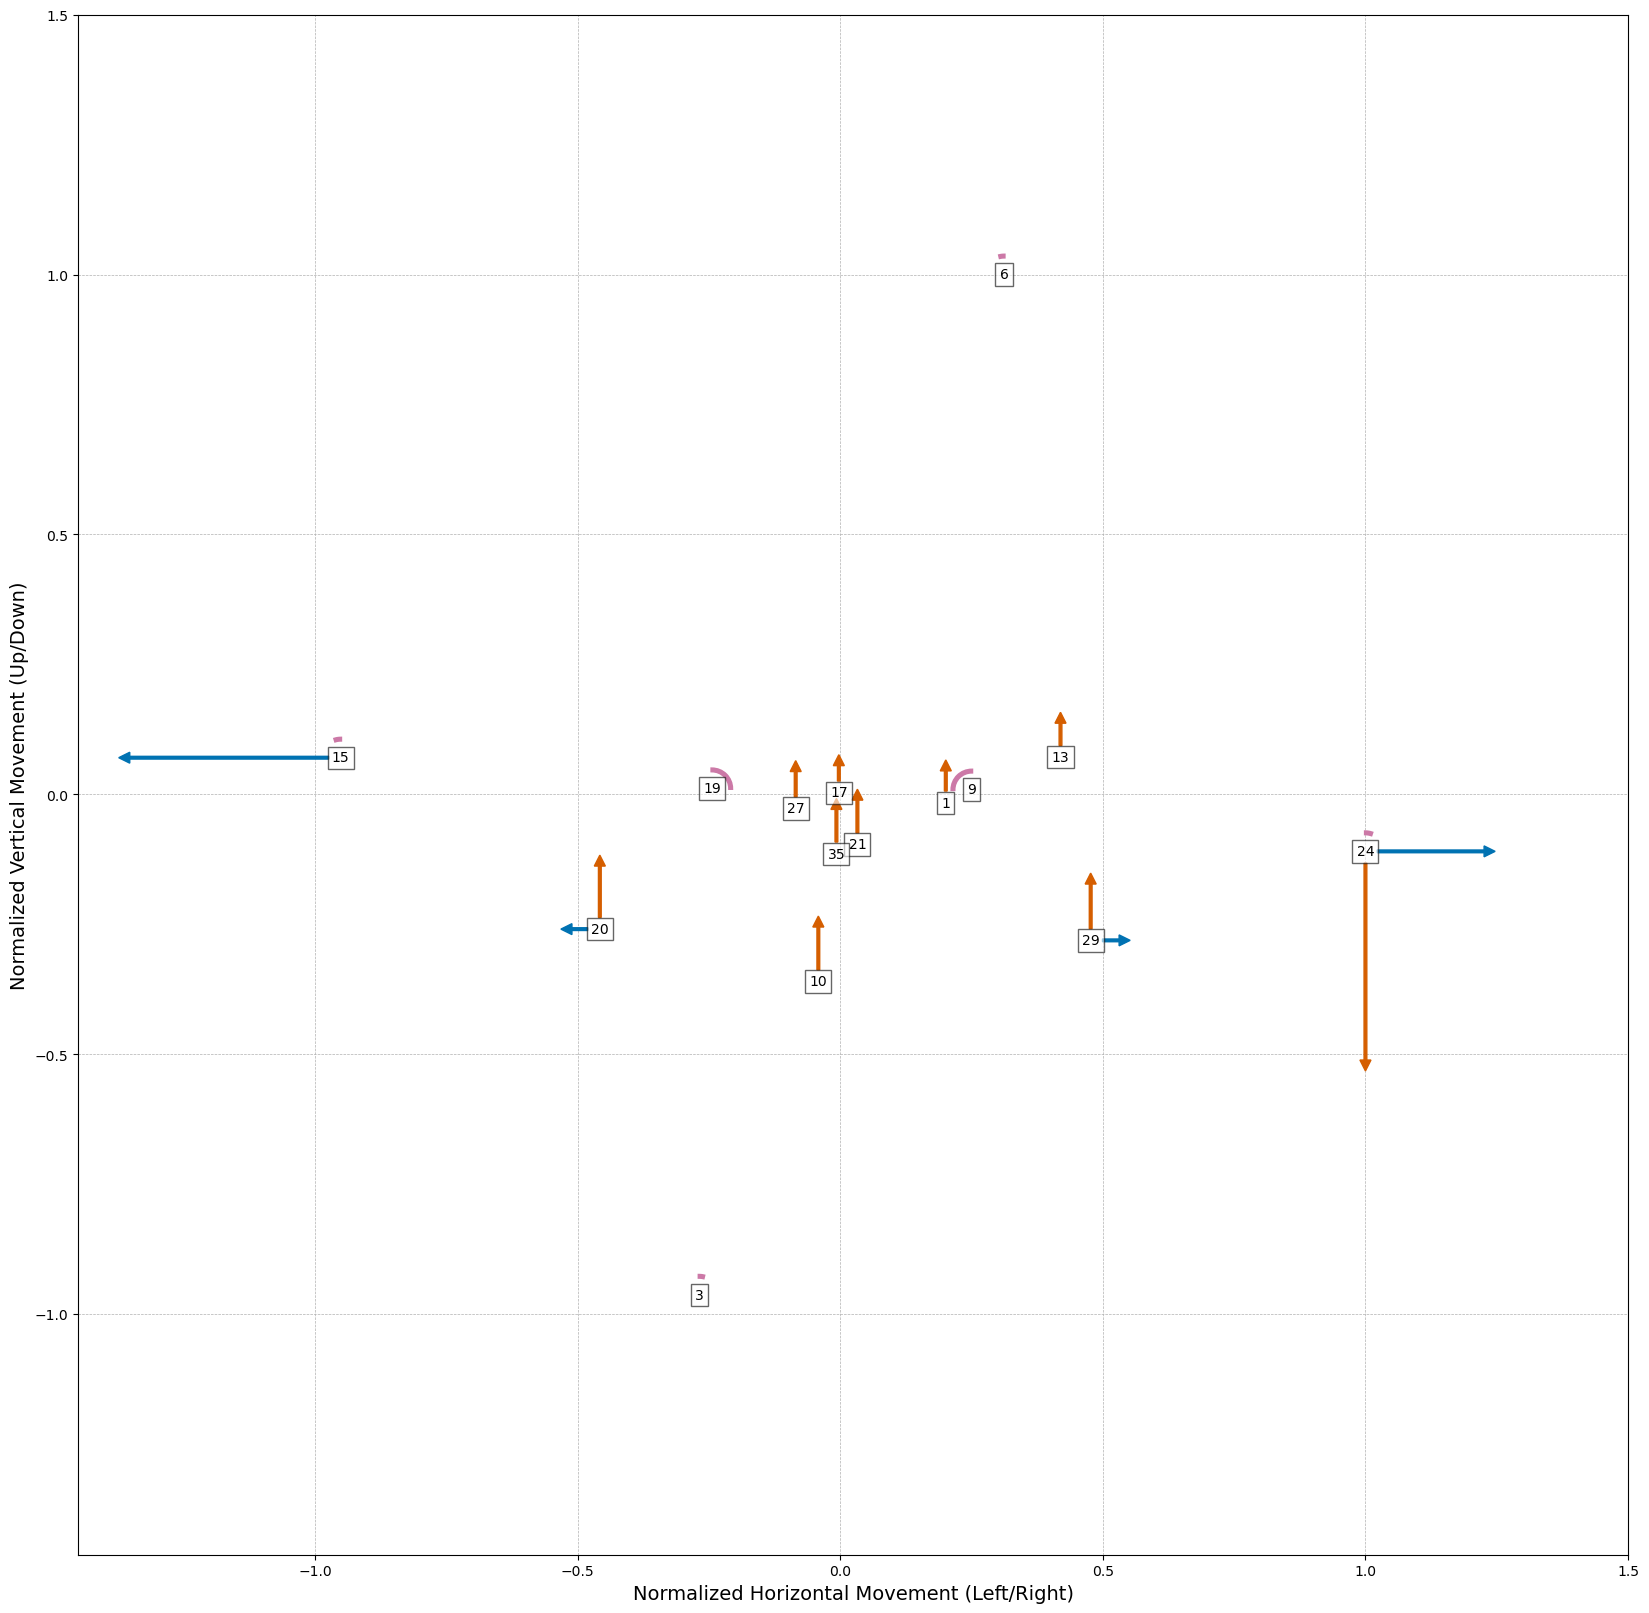

In [433]:

# Compute movement sums
vertical_movement, horizontal_movement = compute_movement_sums(centroids_uf, x_diff_indices, y_diff_indices)

# Normalize movement sums
vertical_movement_norm, horizontal_movement_norm = normalize_movement_sums(vertical_movement, horizontal_movement)

# Normalize centroids for thrust, yaw, slip
columns_to_normalize = ["thrust_mm_s", "yaw_rad_s", "slip_mm_s"]
normalized_centroids = normalize_centroids(centroids_uf, feature_str_overall, columns_to_normalize)

# Specify the clusters to circle and their colors
# cluster_circles = {2: 'green', 3: 'green'}  # For testing
cluster_circles={}
# Plot the clusters with compass visualizations
plot_clusters_with_compass(
    horizontal_movement_norm,
    vertical_movement_norm,
    normalized_centroids,
    feature_str_overall,
    x_scale='linear',     # Change to 'symlog' if needed
    y_scale='linear',     # Change to 'symlog' if needed
    compass_scale=1.5,    # Adjust the compass size
    arrow_head_width_factor=0.7,   # Control arrow head width
    arrow_body_width_factor=0.7,   # Control arrow body width
    yaw_arc_radius_factor=0.5,     # Control yaw arc radius
    circle_radius_factor=0.4,      # Control circle radius around compass
    arrow_length_factor=0.5,
    square_size=0.03,
    cluster_circles=cluster_circles, 
    threshold=0.1
)


# Symlog possible

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, FancyArrowPatch, Circle
from matplotlib import transforms

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized

def normalize_centroids(centroids, feature_labels, columns_to_normalize=None):
    """
    Normalizes specified columns in the centroids to the absolute max value of that feature across all centroids.
    """
    normalized_centroids = np.copy(centroids)
    if columns_to_normalize is None:
        columns_to_normalize = feature_labels
    for feature in columns_to_normalize:
        if isinstance(feature, int):
            col = feature
        else:
            col = feature_labels.index(feature)
        abs_max = np.max(np.abs(centroids[:, col]))
        if abs_max != 0:
            normalized_centroids[:, col] /= abs_max
    return normalized_centroids

def plot_compass(ax, x, y, thrust, yaw, slip, compass_scale=1.0,
                 arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                 yaw_arc_radius_factor=1.0, circle_radius_factor=1.0,
                 circle=False, circle_color='green', circle_style='dotted', arrow_length_factor=1.0):
    """
    Plots the compass visualization at position (x, y) on the given axes.
    Components are only plotted if their absolute values are >= 0.1.
    Sizes are specified in display units to prevent distortion on scaled axes.
    """
    # Threshold for plotting components
    threshold = 0.1

    # Create a transformation that positions the compass at (x, y) in data coordinates
    # and scales sizes in display units (points)
    trans_data = ax.transData
    trans_offset = transforms.Affine2D().translate(x, y)
    transform = trans_offset + trans_data

    # Arrow properties (sizes in points)
    arrow_head_size = 4 * arrow_head_width_factor * compass_scale  # in points
    arrow_line_width = 1 * arrow_body_width_factor * compass_scale  # in points

    # Adjust the compass size (lengths in points)
    compass_size = 20 * compass_scale * arrow_length_factor  # in points

    # Draw thrust arrow
    if abs(thrust) >= threshold:
        thrust_length = thrust * compass_size  # in points
        thrust_arrow = FancyArrowPatch((0, 0), (0, thrust_length),
                                       mutation_scale=arrow_head_size,
                                       arrowstyle='-|>',
                                       color='#D55E00',
                                       linewidth=arrow_line_width,
                                       transform=transform + ax.figure.dpi_scale_trans.inverted())
        ax.add_patch(thrust_arrow)

    # Draw slip arrow
    if abs(slip) >= threshold:
        slip_length = slip * compass_size  # in points
        slip_arrow = FancyArrowPatch((0, 0), (slip_length, 0),
                                     mutation_scale=arrow_head_size,
                                     arrowstyle='-|>',
                                     color='#0072B2',
                                     linewidth=arrow_line_width,
                                     transform=transform + ax.figure.dpi_scale_trans.inverted())
        ax.add_patch(slip_arrow)

    # Draw yaw arc
    if abs(yaw) >= threshold:
        yaw_angle = yaw * 90  # in degrees
        arc_radius = compass_size * 0.5 * yaw_arc_radius_factor  # in points

        # Define the start and end angles
        if yaw > 0:
            theta1 = 90
            theta2 = 90 - yaw_angle
        else:
            theta1 = 90
            theta2 = 90 - yaw_angle

        # Create the transform for the arc
        arc_transform = transform + ax.figure.dpi_scale_trans.inverted()

        # Draw the arc using Wedge
        yaw_arc = Wedge(center=(0, 0), r=arc_radius,
                        theta1=theta1, theta2=theta2,
                        width=arc_radius * 0.2,
                        facecolor='none', edgecolor='#CC79A7',
                        linewidth=arrow_line_width,
                        transform=arc_transform)
        ax.add_patch(yaw_arc)

    # Optionally draw a circle around the compass
    if circle:
        circle_radius = compass_size * circle_radius_factor  # in points
        circle_patch = Circle((0, 0), radius=circle_radius,
                              edgecolor=circle_color,
                              facecolor='none',
                              linestyle=circle_style,
                              linewidth=1.5,
                              transform=transform + ax.figure.dpi_scale_trans.inverted())
        ax.add_patch(circle_patch)


In [412]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, FancyArrowPatch, Circle, Rectangle
from matplotlib import transforms

def get_diff_indices(feature_names):
    x_diff_indices = []
    y_diff_indices = []
    for i, s in enumerate(feature_names):
        if 'x_diff' in s:
            x_diff_indices.append(i)
        elif 'y_diff' in s:
            y_diff_indices.append(i)
    return x_diff_indices, y_diff_indices

def compute_movement_sums(centroids, x_diff_indices, y_diff_indices):
    # Apply negative sign to match the 'Up' (-x) and 'Left' (-y) directions
    vertical_movement = -centroids[:, x_diff_indices].sum(axis=1)  # Vertical (Up/Down)
    horizontal_movement = -centroids[:, y_diff_indices].sum(axis=1)  # Horizontal (Left/Right)
    return vertical_movement, horizontal_movement

def normalize_movement_sums(vertical_movement, horizontal_movement):
    max_vertical = np.max(np.abs(vertical_movement))
    max_horizontal = np.max(np.abs(horizontal_movement))
    vertical_movement_normalized = vertical_movement / max_vertical if max_vertical != 0 else vertical_movement
    horizontal_movement_normalized = horizontal_movement / max_horizontal if max_horizontal != 0 else horizontal_movement
    return vertical_movement_normalized, horizontal_movement_normalized

def normalize_centroids(centroids, feature_labels, columns_to_normalize=None):
    """
    Normalizes specified columns in the centroids to the absolute max value of that feature across all centroids.
    """
    normalized_centroids = np.copy(centroids)
    if columns_to_normalize is None:
        columns_to_normalize = feature_labels
    for feature in columns_to_normalize:
        if isinstance(feature, int):
            col = feature
        else:
            col = feature_labels.index(feature)
        abs_max = np.max(np.abs(centroids[:, col]))
        if abs_max != 0:
            normalized_centroids[:, col] /= abs_max
    return normalized_centroids

def plot_compass(ax, x, y, thrust, yaw, slip, compass_scale=1.0,
                 arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                 yaw_arc_radius_factor=1.0, circle_radius_factor=1.0,
                 circle=False, circle_color='green', circle_style='dotted', arrow_length_factor=1.0,
                 square_size=0.01):
    """
    Plots the compass visualization at position (x, y) on the given axes.
    Components are only plotted if their absolute values are >= 0.1.
    Sizes are specified in display units to prevent distortion on scaled axes.
    """
    # Threshold for plotting components
    threshold = 0.1

    # Create a transformation that positions the compass at (x, y) in data coordinates
    # and scales sizes in display units (points or pixels)
    trans_data = ax.transData
    trans_offset = transforms.Affine2D().translate(x, y)
    transform = trans_offset + trans_data

    # Arrow properties (sizes in points)
    arrow_head_size = 4 * arrow_head_width_factor * compass_scale  # in points
    arrow_line_width = 1 * arrow_body_width_factor * compass_scale  # in points

    # Adjust the compass size (lengths in points)
    compass_size = 20 * compass_scale * arrow_length_factor  # in points

    # Draw the white square at the center
    # Sizes in points
    square_size_pts = 6 * compass_scale  # Adjust as needed
    square = Rectangle((-square_size_pts/2, -square_size_pts/2), square_size_pts, square_size_pts,
                       facecolor='white', edgecolor='black', linewidth=1.5,
                       transform=transform + ax.figure.dpi_scale_trans.inverted(), zorder=3)
    ax.add_patch(square)

    # Draw thrust arrow
    if abs(thrust) >= threshold:
        thrust_length = thrust * compass_size  # in points
        thrust_arrow = FancyArrowPatch((0, 0), (0, thrust_length),
                                       mutation_scale=arrow_head_size,
                                       arrowstyle='-|>',
                                       color='#D55E00',
                                       linewidth=arrow_line_width,
                                       transform=transform + ax.figure.dpi_scale_trans.inverted(),
                                       zorder=4)
        ax.add_patch(thrust_arrow)

    # Draw slip arrow
    if abs(slip) >= threshold:
        slip_length = slip * compass_size  # in points
        slip_arrow = FancyArrowPatch((0, 0), (slip_length, 0),
                                     mutation_scale=arrow_head_size,
                                     arrowstyle='-|>',
                                     color='#0072B2',
                                     linewidth=arrow_line_width,
                                     transform=transform + ax.figure.dpi_scale_trans.inverted(),
                                     zorder=4)
        ax.add_patch(slip_arrow)

    # Draw yaw arc
    if abs(yaw) >= threshold:
        yaw_angle = yaw * 90  # in degrees
        arc_radius = compass_size * 0.5 * yaw_arc_radius_factor  # in points

        # Define the start and end angles
        if yaw > 0:
            theta1 = 90
            theta2 = 90 - yaw_angle
        else:
            theta1 = 90
            theta2 = 90 - yaw_angle

        # Create the transform for the arc
        arc_transform = transform + ax.figure.dpi_scale_trans.inverted()

        # Draw the arc using Wedge
        yaw_arc = Wedge(center=(0, 0), r=arc_radius,
                        theta1=theta1, theta2=theta2,
                        width=arc_radius * 0.2,
                        facecolor='#CC79A7', edgecolor='#CC79A7',
                        linewidth=arrow_line_width,
                        transform=arc_transform, zorder=4)
        ax.add_patch(yaw_arc)

    # Optionally draw a circle around the compass
    if circle:
        circle_radius = compass_size * circle_radius_factor  # in points
        circle_patch = Circle((0, 0), radius=circle_radius,
                              edgecolor=circle_color,
                              facecolor='none',
                              linestyle=circle_style,
                              linewidth=1.5,
                              transform=transform + ax.figure.dpi_scale_trans.inverted(),
                              zorder=2)
        ax.add_patch(circle_patch)

def plot_clusters_with_compass(horizontal_movement, vertical_movement, normalized_centroids, feature_labels, 
                               x_scale='linear', y_scale='linear', x_linthresh=0.01, y_linthresh=0.01,
                               compass_scale=1.0, 
                               arrow_head_width_factor=1.0, arrow_body_width_factor=1.0,
                               yaw_arc_radius_factor=1.0, circle_radius_factor=1.0, arrow_length_factor=1.0,
                               square_size=0.01, cluster_circles=None):
    """
    Plots the clusters with compass visualizations.
    """
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    ax.set_xlabel('Normalized Horizontal Movement (Left/Right)')
    ax.set_ylabel('Normalized Vertical Movement (Up/Down)')
    plt.title('Cluster Movements with Compass Visualizations')
    
    # Set scales
    if x_scale == 'symlog':
        ax.set_xscale('symlog', linthresh=x_linthresh, linscale=1)
    else:
        ax.set_xscale(x_scale)
    if y_scale == 'symlog':
        ax.set_yscale('symlog', linthresh=y_linthresh, linscale=1)
    else:
        ax.set_yscale(y_scale)
    
    # Plot compass at each cluster point
    num_clusters = len(horizontal_movement)
    
    thrust_idx = feature_labels.index("thrust_mm_s")
    yaw_idx = feature_labels.index("yaw_rad_s")
    slip_idx = feature_labels.index("slip_mm_s")
    
    for i in range(num_clusters):
        x = horizontal_movement[i]
        y = vertical_movement[i]
        thrust = normalized_centroids[i, thrust_idx]
        yaw = normalized_centroids[i, yaw_idx]
        slip = normalized_centroids[i, slip_idx]
        
        # Determine if this cluster needs a circle
        circle = False
        circle_color = 'green'
        circle_style = 'dotted'
        if cluster_circles is not None and i in cluster_circles:
            circle = True
            circle_color = cluster_circles[i]
        
        # Plot compass at (x, y)
        plot_compass(ax, x, y, thrust, yaw, slip,
                     compass_scale=compass_scale,
                     arrow_head_width_factor=arrow_head_width_factor,
                     arrow_body_width_factor=arrow_body_width_factor,
                     yaw_arc_radius_factor=yaw_arc_radius_factor,
                     circle_radius_factor=circle_radius_factor,
                     circle=circle, circle_color=circle_color, circle_style=circle_style,
                     arrow_length_factor=arrow_length_factor, square_size=square_size,threshold=threshold)
        
        # Plot the cluster index as text without a visible point
        ax.text(x, y, str(i), fontsize=10, ha='center', va='center', zorder=5, color='black',
                bbox=dict(facecolor='white', alpha=0.6, boxstyle='round,pad=0.3'))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()


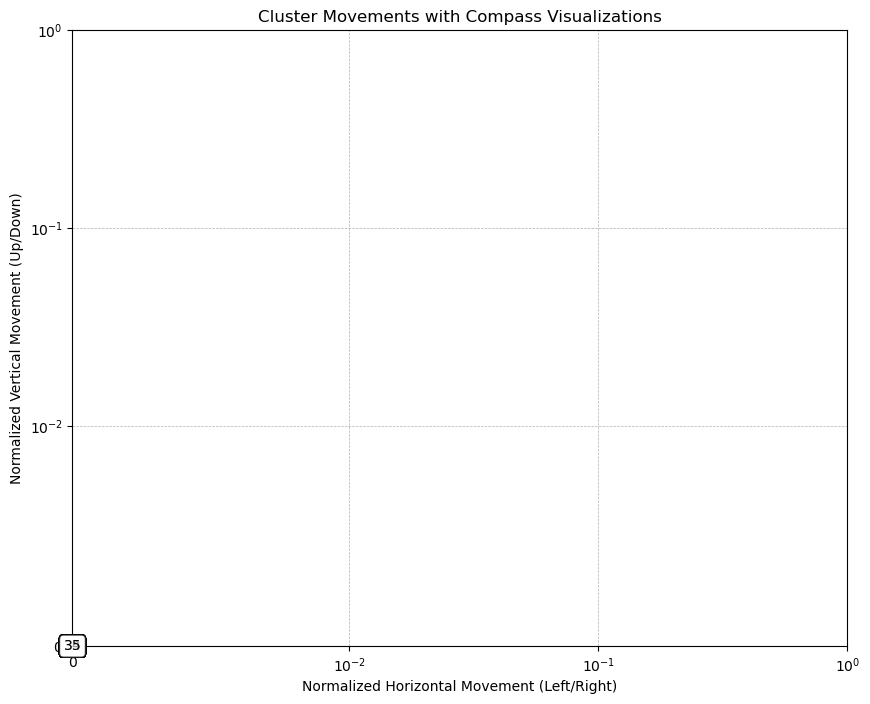

In [413]:
vertical_movement, horizontal_movement = compute_movement_sums(centroids_uf, x_diff_indices, y_diff_indices)

# Normalize movement sums
vertical_movement_norm, horizontal_movement_norm = normalize_movement_sums(vertical_movement, horizontal_movement)

# Normalize centroids for thrust, yaw, slip
columns_to_normalize = ["thrust_mm_s", "yaw_rad_s", "slip_mm_s"]
normalized_centroids = normalize_centroids(centroids_uf, feature_str_overall, columns_to_normalize)

# Specify the clusters to circle and their colors
cluster_circles = {2: 'green', 3: 'green'}  # For testing

# Plot the clusters with compass visualizations
plot_clusters_with_compass(
    horizontal_movement_norm,
    vertical_movement_norm,
    normalized_centroids,
    feature_str_overall,
    x_scale='symlog',     # Use 'symlog' scale
    y_scale='symlog',     # Use 'symlog' scale
    x_linthresh=0.01,     # linthresh for x-axis
    y_linthresh=0.01,     # linthresh for y-axis
    compass_scale=1.0,    # Adjust the compass size
    arrow_head_width_factor=1.0,   # Control arrow head width
    arrow_body_width_factor=1.0,   # Control arrow body width
    yaw_arc_radius_factor=1.0,     # Control yaw arc radius
    circle_radius_factor=1.0,      # Control circle radius around compass
    arrow_length_factor=1.0,       # Control arrow length
    square_size=0.01,              # Size of the square at the center
    cluster_circles=cluster_circles
)